# IMEN266 · Ch.8 · Class Problems 12 — Finite capacity, Erlang loss, truncation, $M/G/1$, bulk arrivals, reneging

**How this notebook works** — every problem follows the same 5 steps:

> **Problem → Model → Analytic → Simulate & Visualize → Experiment**

The analytic answer and the simulation must agree. *That agreement — not the
instructor, not an AI — is your ground truth.*

**In-class version only:** cells marked `# TODO` are for you to complete during
class. A `check(...)` cell right after tells you immediately whether your answer
matches the reference value.

▶ Open in Colab: `https://colab.research.google.com/github/youngmko/imen266-2026/blob/main/ch08/notebooks/CP12_finite_capacity_variations.ipynb`

**The facts of this notebook** *(slides pp. 23–46/66; Companion Proofs 5–7)*

- **Finite capacity:** the cut equations stop at $K$ — a finite sum, no stability
  condition. The recipe: $p_K$ (loss probability, by PASTA) $\to$ effective arrival rate
  $\lambda(1-p_K)$ $\to$ Little's law with that rate. $M/M/K/K$: **Erlang loss formula**,
  valid for $M/G/K/K$ (insensitivity).
- **Truncation:** restricting a time-reversible chain to a subset $S'$ only renormalises
  its weights: $p^B_j=p^A_j/\sum_{S'}p^A_i$ — $M/M/2/K$ from $M/M/2$ (2025 final), $M/M/K/K$ from
  $M/M/\infty$.
- **Pollaczek–Khinchine:** $L_q=\frac{\lambda^2\sigma^2+\rho^2}{2(1-\rho)}$ — only the mean and the
  variance of the service time matter. **Bulk arrivals:** $L=\frac{\rho+(\lambda/\mu)E[X^2]}{2(1-\rho)}$,
  $\rho=\lambda E[X]/\mu$. **Reneging / balking:** still a birth–death chain, with
  state-dependent rates.

In code (`imen266.queueing`): `mm1k`, `mmsk`, `mmkk`, `erlang_b`, `truncate`, `birth_death_stationary`,
`mg1_pk`, `bulk_mm1`, `reneging_balking_rates`, `gg1_approx`, `ggm_approx`, and the simulator
`simulate_queue(arrival, service, T, rng, s=, K=, patience=, balk=)`.

In [1]:
# --- IMEN266 setup (Ch.8): course package + helpers ---------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

try:                                   # local clone / PLMS zip: package is on the path
    from imen266.queueing import mm1
except ImportError:                    # Colab: fetch the course package from GitHub (~5 s)
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/youngmko/imen266-2026.git"], check=True)
    from imen266.queueing import mm1
from imen266.queueing import (mms, mminf, mm1k, mmsk, mmkk, erlang_b, erlang_c,
                              birth_death_stationary, truncate, mm1_sojourn_tail, mm1_required_rate,
                              mg1_pk, bulk_mm1, gg1_approx, ggm_approx, reneging_balking_rates,
                              jackson_solve, optimal_split, pooling_compare, braess,
                              SimQueue, simulate_queue, sim_network, little_check, pasta_demo)
from imen266.ctmc import CTMC, birth_death, bd_stationary, poisson_process
from imen266.check import check        # [TODO]/[OK]/[X] self-check (unfinished TODOs never crash)

rng = np.random.default_rng(2026)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11,
                     "legend.frameon": False})

def plot_queue_path(res, T_show=None, ax=None, title=None):
    """Step plot of the number in the system N(t) from a SimQueue / simulate_queue result."""
    ax = ax or plt.gca()
    t, n = res["t"], res["n"]
    if T_show is not None:
        m = t <= T_show
        t, n = np.append(t[m], T_show), np.append(n[m], n[m][-1])
    ax.step(t, n, where="post", lw=1)
    ax.set_xlabel("t"); ax.set_ylabel("number in system N(t)")
    if title: ax.set_title(title)
    return ax

def bd_diagram(births, deaths, states=None, ax=None):
    """Rate diagram of a finite birth-death chain (reuses CTMC.plot_rate_diagram, line layout)."""
    chain = birth_death(births, deaths, states=states)
    return chain.plot_rate_diagram(ax=ax, layout="line")

def ci95(x):
    """Half-width of a 95% confidence interval for the mean of the replications x."""
    x = np.asarray(x, dtype=float)
    return 1.96 * x.std(ddof=1) / math.sqrt(len(x)) if len(x) > 1 else np.nan

try:
    from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider
    HAS_W = True
except Exception:
    HAS_W = False

def show(fn, **sliders):
    """interact() if widgets are available; otherwise draw once with defaults."""
    if HAS_W:
        interact(fn, **sliders)
    else:
        fn(**{k: getattr(v, "value", v) for k, v in sliders.items()})

print("Setup OK.  imen266.queueing imported.  Widgets available:", HAS_W)

Setup OK.  imen266.queueing imported.  Widgets available: True


---
## Problem 1 — $M/M/1/K$: a car wash with four spaces *(slides pp. 23–24/66)*

> A single-bay car wash has room for 4 cars altogether (one being washed, three
> waiting); a car that finds the lot full drives on. Cars arrive according to $PP(\lambda)$
> with $\lambda=6$ per hour and a wash takes $\exp(\mu)$, $1/\mu=10$ min. What fraction of
> cars is lost, how many cars are in the lot on average, and how long does a car that
> enters stay?

### Model
$M/M/1/K$ with $K=4$ and $\lambda=\mu$: $p_i=1/(K+1)$ (slide p. 23/66). $p_K$ is the loss
fraction; the cars that enter arrive at rate $\lambda(1-p_K)$, so $W=L/(\lambda(1-p_K))$,
$W_q=W-1/\mu$, $L_q=\lambda(1-p_K)W_q$ (slide p. 24/66).

In [3]:
lam, mu, K = 6.0, 6.0, 4                                       # per hour
p = np.full(K + 1, 1 / (K + 1))                                # lam = mu: uniform
pK = p[-1]
L = (np.arange(K + 1) * p).sum()
lam_eff = lam * (1 - pK)
W_min = L / lam_eff * 60                                       # minutes
Wq_min = W_min - 60 / mu
print(f"p_K = {pK:.3f}   L = {L:.3f}   lam_eff = {lam_eff:.2f}/h   W = {W_min:.1f} min   Wq = {Wq_min:.1f} min   (naive L/lam = {60*L/lam:.1f} min)")

p_K = 0.200   L = 2.000   lam_eff = 4.80/h   W = 25.0 min   Wq = 15.0 min   (naive L/lam = 20.0 min)


In [4]:
check("loss fraction p_K",          pK,      0.2,  tol=1e-9)
check("L",                           L,       2.0,  tol=1e-9)
check("effective arrival rate (/h)", lam_eff, 4.8,  tol=1e-9)
check("W in minutes",                W_min,   25.0, tol=1e-6)
check("Wq in minutes",               Wq_min,  15.0, tol=1e-6)

[OK ] loss fraction p_K: got 0.2   (reference 0.2)
[OK ] L: got 2   (reference 2)
[OK ] effective arrival rate (/h): got 4.8   (reference 4.8)
[OK ] W in minutes: got 25   (reference 25)
[OK ] Wq in minutes: got 15   (reference 15)


True

simulation: loss 0.1998  L 1.992  W 24.9 min  Wq 14.9 min  entering rate 4.810/h
theory:     loss 0.2000  L 2.000  W 25.0 min  Wq 15.0 min  entering rate 4.800/h


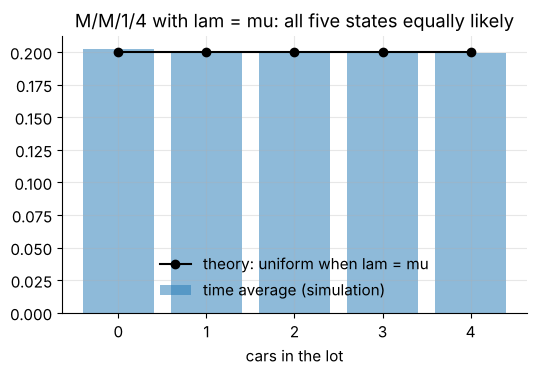

In [5]:
# --- Simulate the lot: lost cars are counted, entering cars are timed -------------------------------------------
ref = mm1k(6.0, 6.0, 4)                                                   # independent of your TODO
res = simulate_queue(6.0, 6.0, T=30_000, rng=rng, K=4, warmup=300)
print(f"simulation: loss {res['loss_fraction']:.4f}  L {res['L']:.3f}  W {60*res['W']:.1f} min  Wq {60*res['Wq']:.1f} min  entering rate {res['lam_eff']:.3f}/h")
print(f"theory:     loss {ref['pK']:.4f}  L {ref['L']:.3f}  W {60*ref['W']:.1f} min  Wq {60*ref['Wq']:.1f} min  entering rate {ref['lam_eff']:.3f}/h")
n = np.arange(5)
plt.figure(figsize=(6, 3.6)); plt.bar(n, res["p_time"][:5], alpha=.5, label="time average (simulation)"); plt.plot(n, ref["p"], "ko-", label="theory: uniform when lam = mu")
plt.xlabel("cars in the lot"); plt.legend(); plt.title("M/M/1/4 with lam = mu: all five states equally likely"); plt.show()

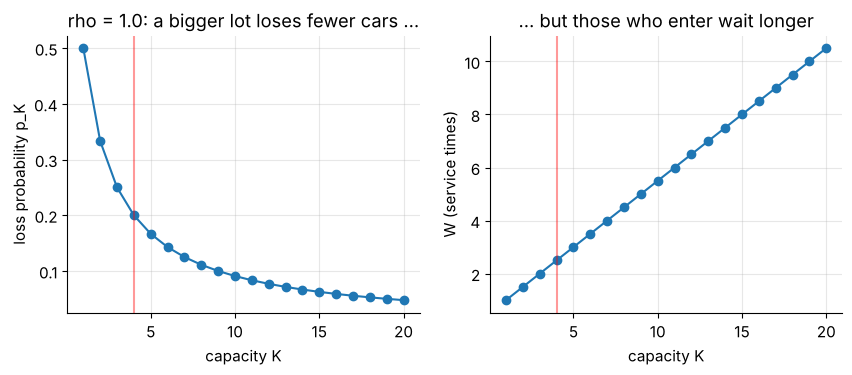

In [6]:
def mm1k_demo(rho=1.0, K=4):
    """Loss probability and W (in service times) of M/M/1/K as functions of K, for a chosen rho = lam/mu."""
    KK = np.arange(1, 21)
    loss = np.array([mm1k(rho, 1.0, k)["pK"] for k in KK]); W = np.array([mm1k(rho, 1.0, k)["W"] for k in KK])
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    ax[0].plot(KK, loss, "o-"); ax[0].set_xlabel("capacity K"); ax[0].set_ylabel("loss probability p_K"); ax[0].set_title(f"rho = {rho}: a bigger lot loses fewer cars ...")
    ax[1].plot(KK, W, "o-"); ax[1].set_xlabel("capacity K"); ax[1].set_ylabel("W (service times)"); ax[1].set_title("... but those who enter wait longer")
    if rho < 1: ax[1].axhline(1 / (1 - rho), color="gray", ls=":", label="M/M/1 limit"); ax[1].legend(fontsize=8)
    for a in ax: a.axvline(K, color="r", alpha=.4)
    plt.show()

show(mm1k_demo, rho=FloatSlider(min=0.3, max=2.0, step=0.1, value=1.0) if HAS_W else 1.0,
     K=IntSlider(min=1, max=20, value=4) if HAS_W else 4)

**Think about it** — (i) With $\rho>1$ the $M/M/1$ queue explodes, the $M/M/1/K$ queue does
not; what does $p_K$ tend to as $\rho\to\infty$? (ii) Why is $L/\lambda$ wrong for $W$ — which
customers does Little's law count? (iii) Design question: the owner can add one more
waiting space or speed the wash up by 10 %; which reduces the loss more at $\lambda=\mu$?

---
## Problem 2 — $M/M/s/K$: the Example $M/M/5/5$ of the slides, and a fast-food counter *(slides pp. 25–26, 29–30/66; homework09 Q5 of 2025)*

> (a) $M/M/5/5$: $\lambda=5$ per hour, $1/\mu=12$ min. What fraction of customers is
> rejected? $L$? $W$? (b) A fast-food take-out has two servers and room for 4
> customers in total; potential customers arrive as $PP(3)$ per minute and a service
> takes $\exp(\mu)$ with $1/\mu=30$ s. Compute $L$ and $W$.

### Model
(a) $M/M/K/K$ with $a=\lambda/\mu=1$: $p_5=\frac{1/5!}{\sum_{i\le5}1/i!}=\frac1{326}$,
$L=\lambda(1-p_5)/\mu=\frac{325}{326}$, $W=\frac{L}{\lambda(1-p_5)}=\frac15$ h (slide p. 30/66).
(b) $M/M/2/4$ with $a=1.5$: weights $a^i/i!$ for $i\le2$ and $\frac{a^2}{2}(\frac a2)^{i-2}$ for $i=3,4$
(slide p. 25/66), then the finite-capacity recipe.

In [7]:
# (a) M/M/5/5
w = np.array([1 / math.factorial(i) for i in range(6)])          # a = 1
p5 = w[5] / w.sum()
L5 = (np.arange(6) * w).sum() / w.sum()
W5_min = L5 / (5 * (1 - p5)) * 60
# (b) M/M/2/4, lam = 3/min, mu = 2/min
a = 3 / 2
w2 = np.array([1, a, a**2 / 2, a**2 / 2 * (a / 2), a**2 / 2 * (a / 2) ** 2])
p24 = w2 / w2.sum()
L24 = (np.arange(5) * p24).sum()
W24 = L24 / (3 * (1 - p24[4]))                                  # minutes
print(f"(a) p5 = 1/{1/p5:.0f} = {p5:.5f}   L = {L5:.4f}   W = {W5_min:.1f} min")
print(f"(b) p = {p24.round(4)}   loss {p24[4]:.4f}   L = {L24:.4f}   W = {W24:.4f} min = {60*W24:.1f} s")

(a) p5 = 1/326 = 0.00307   L = 0.9969   W = 12.0 min
(b) p = [0.196  0.294  0.2205 0.1654 0.124 ]   loss 0.1240   L = 1.7274   W = 0.6573 min = 39.4 s


In [8]:
ref = mmsk(3.0, 2.0, 2, 4)
check("(a) p5 = 1/326",       p5,     1/326,     tol=1e-9)
check("(a) L = 325/326",      L5,     325/326,   tol=1e-9)
check("(a) W = 12 min",       W5_min, 12.0,      tol=1e-6)
check("(b) loss p4 of M/M/2/4", None if p24 is Ellipsis else p24[4], ref["pK"], tol=1e-6)
check("(b) L of M/M/2/4",     L24,    ref["L"],  tol=1e-6)
check("(b) W of M/M/2/4 (min)", W24,  ref["W"],  tol=1e-6)

[OK ] (a) p5 = 1/326: got 0.00306748   (reference 0.00306748)
[OK ] (a) L = 325/326: got 0.996933   (reference 0.996933)
[OK ] (a) W = 12 min: got 12   (reference 12)
[OK ] (b) loss p4 of M/M/2/4: got 0.124043   (reference 0.124043)
[OK ] (b) L of M/M/2/4: got 1.72741   (reference 1.72741)
[OK ] (b) W of M/M/2/4 (min): got 0.657343   (reference 0.657343)


True

(a) M/M/5/5: loss sim 0.00308 (theory 0.00307 = 1/326)   L sim 0.9954 (theory 0.9969)   W sim 11.97 min (12)
(b) M/M/2/4: loss sim 0.1261 (theory 0.1240)   L sim 1.7353 (theory 1.7274)   W sim 0.6593 min (theory 0.6573)   Wq sim 0.1592 (0.1573)


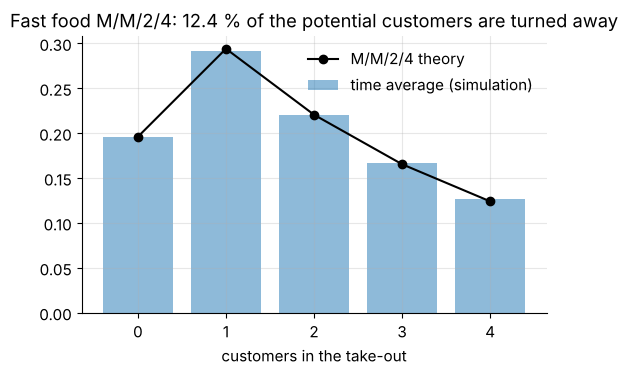

In [9]:
# --- Simulate both systems ------------------------------------------------------------------------------
ra, rb = mmkk(5.0, 5.0, 5), mmsk(3.0, 2.0, 2, 4)                       # independent of your TODO
sa = simulate_queue(5.0, 5.0, T=40_000, rng=rng, s=5, K=5, warmup=200)
sb = simulate_queue(3.0, 2.0, T=20_000, rng=rng, s=2, K=4, warmup=100)
print(f"(a) M/M/5/5: loss sim {sa['loss_fraction']:.5f} (theory {ra['pK']:.5f} = 1/326)   L sim {sa['L']:.4f} (theory {ra['L']:.4f})   W sim {60*sa['W']:.2f} min (12)")
print(f"(b) M/M/2/4: loss sim {sb['loss_fraction']:.4f} (theory {rb['pK']:.4f})   L sim {sb['L']:.4f} (theory {rb['L']:.4f})   W sim {sb['W']:.4f} min (theory {rb['W']:.4f})   Wq sim {sb['Wq']:.4f} ({rb['Wq']:.4f})")
n = np.arange(5)
plt.figure(figsize=(6, 3.6)); plt.bar(n, sb["p_time"][:5], alpha=.5, label="time average (simulation)"); plt.plot(n, rb["p"], "ko-", label="M/M/2/4 theory")
plt.xlabel("customers in the take-out"); plt.legend(); plt.title("Fast food M/M/2/4: 12.4 % of the potential customers are turned away"); plt.show()

**Think about it** — (i) In (a), $W$ is exactly one service time; why is that obvious
without any formula? (ii) In (b), what are $L_q$ and $W_q$, and which of the two numbers
would the manager rather reduce — by a third server, or by one more standing place?
(Try `mmsk(3, 2, 3, 5)` and `mmsk(3, 2, 2, 5)`.)

---
## Problem 3 — Erlang loss: how many telephone lines to lease? *(slides pp. 27–28, 45–46/66; homework09 Q3 of 2025)*

> A small telephone company leases $K$ lines from a big carrier at $d$ won per line per
> second. Calls arrive as $PP(\lambda)$, $\lambda=2$ per second, and last a random time
> with mean $1/\mu=3$ s (any distribution: the system is $M/G/K/K$). A call that finds all
> lines busy is lost; the company earns $c=1$ won per second per line in use. Long-run
> revenue per second, and the best $K$ for $d=0.5$?

### Model
Offered load $a=\lambda/\mu=6$; the loss probability is Erlang B,
$p_K=\frac{a^K/K!}{\sum_{j\le K}a^j/j!}$ (slide p. 28/66), the mean number of busy lines is
$a(1-p_K)$, so the revenue rate is $R(K)=c\,a\,(1-p_K)-dK$.

In [10]:
lam, m_call, c, d = 2.0, 3.0, 1.0, 0.5
a = lam * m_call
KK = np.arange(1, 16)
B = np.array([erlang_b(a, k) for k in KK])                      # Erlang B, stable recursion
R = c * a * (1 - B) - d * KK
K_best = int(KK[np.argmax(R)])
print(f"a = {a}:  B(6) = {B[5]:.4f}, R(6) = {R[5]:.3f};  best K = {K_best} with R = {R.max():.3f} won/s")

a = 6.0:  B(6) = 0.2649, R(6) = 1.410;  best K = 6 with R = 1.410 won/s


In [11]:
check("Erlang B at K = 6, a = 6", None if B is Ellipsis else B[5], erlang_b(6, 6), tol=1e-6)
check("revenue rate at K = 6",     None if R is Ellipsis else R[5], 6*(1 - erlang_b(6, 6)) - 3, tol=1e-6)
check("best K",                    K_best, 6, tol=1e-9)

[OK ] Erlang B at K = 6, a = 6: got 0.264922   (reference 0.264922)
[OK ] revenue rate at K = 6: got 1.41047   (reference 1.41047)
[OK ] best K: got 6   (reference 6)


True

theory: loss = Erlang B = 0.2649, busy lines = 4.410
       exponential: loss 0.2638   busy lines 4.408


 deterministic 3 s: loss 0.2664   busy lines 4.423
   lognormal, cv 2: loss 0.2604   busy lines 4.398


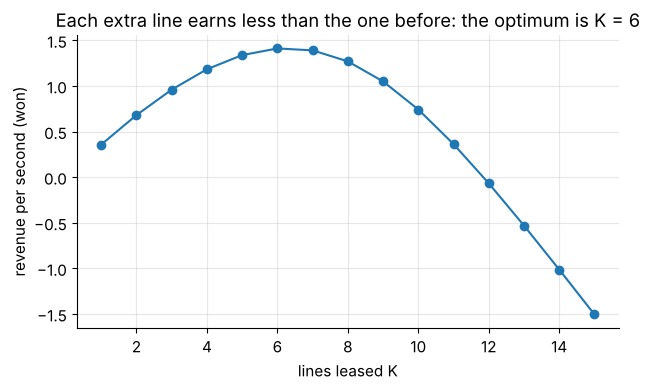

In [12]:
# --- Insensitivity: simulate M/G/6/6 with three service laws of mean 3 s --------------------------------------
B6 = erlang_b(6.0, 6)
laws = {"exponential": 1/3.0,
        "deterministic 3 s": lambda r, n: np.full(n, 3.0),
        "lognormal, cv 2": lambda r, n: r.lognormal(math.log(3) - 0.5*math.log(5), math.sqrt(math.log(5)), n)}
print(f"theory: loss = Erlang B = {B6:.4f}, busy lines = {6*(1-B6):.3f}")
for name, svc in laws.items():
    r = simulate_queue(2.0, svc, T=20_000, rng=rng, s=6, K=6, warmup=100)
    print(f"{name:>18}: loss {r['loss_fraction']:.4f}   busy lines {r['busy']:.3f}")
Rref = 1.0 * 6 * (1 - np.array([erlang_b(6.0, k) for k in range(1, 16)])) - 0.5 * np.arange(1, 16)   # independent of your TODO
plt.figure(figsize=(7, 3.8)); plt.plot(np.arange(1, 16), Rref, "o-"); plt.xlabel("lines leased K"); plt.ylabel("revenue per second (won)")
plt.title("Each extra line earns less than the one before: the optimum is K = 6"); plt.show()

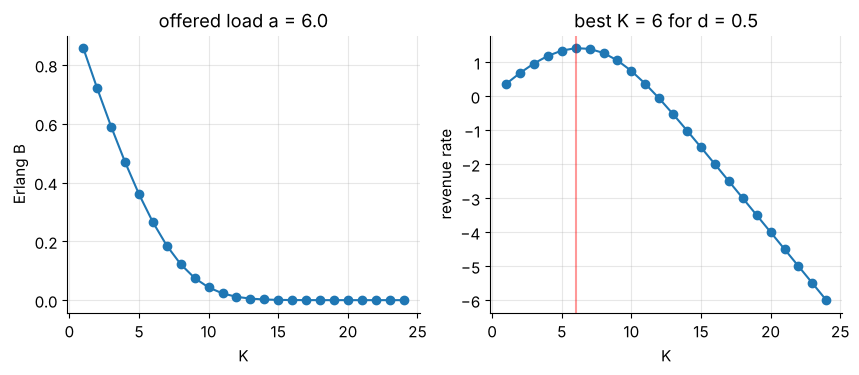

In [13]:
def erlang_demo(a=6.0, d=0.5):
    """Erlang B and the revenue curve for offered load a and line cost d (c = 1)."""
    KK = np.arange(1, 25); B = np.array([erlang_b(a, k) for k in KK]); R = a * (1 - B) - d * KK
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    ax[0].plot(KK, B, "o-"); ax[0].set_xlabel("K"); ax[0].set_ylabel("Erlang B"); ax[0].set_title(f"offered load a = {a}")
    ax[1].plot(KK, R, "o-"); ax[1].axvline(KK[np.argmax(R)], color="r", alpha=.4); ax[1].set_xlabel("K"); ax[1].set_ylabel("revenue rate"); ax[1].set_title(f"best K = {KK[np.argmax(R)]} for d = {d}")
    plt.show()

show(erlang_demo, a=FloatSlider(min=1, max=20, step=0.5, value=6.0) if HAS_W else 6.0,
     d=FloatSlider(min=0.05, max=1.0, step=0.05, value=0.5) if HAS_W else 0.5)

**Think about it** — (i) The marginal value of the $K$-th line is $c\,a\,(B(K-1)-B(K))$; why
is it decreasing in $K$? (ii) Which fact of this chapter says that the call-length
*distribution* does not matter? (Companion Proof 5.) (iii) With $a=6$, how many lines
give a loss below 1 %? Compare with the revenue-optimal $K$ and explain the gap.

---
## Problem 4 — Final-style: $M/M/2/K$ by truncation *(slides pp. 42–46/66; 2025 final Q3)*

> Calculate the steady-state probabilities of the $M/M/2/K$ queue ($K>2$) using time
> reversibility and the $M/M/2$ result of the lecture — **do not solve $pQ=0$ directly.**

### Model
$M/M/2$ is a birth–death chain, hence reversible, with weights $w_0=1$,
$w_j=\frac\lambda\mu\big(\frac\lambda{2\mu}\big)^{j-1}$ ($j\ge1$). Truncation to $\{0,\ldots,K\}$ renormalises:
$p^{(K)}_j=w_j/\sum_{i\le K}w_i$ (slide p. 44/66). Numbers: $\lambda=\mu=1$, $K=4$ — note that the
untruncated $M/M/2$ is stable here ($\lambda<2\mu$), but the recipe does not even need that.

In [14]:
lam, mu, K = 1.0, 1.0, 4
w = np.array([1.0] + [(lam / mu) * (lam / (2 * mu)) ** (j - 1) for j in range(1, K + 1)])
p_trunc = w / w.sum()
print("weights", w, "\np^(K) =", p_trunc.round(4), "  loss p_K =", p_trunc[-1].round(4))

weights [1.    1.    0.5   0.25  0.125] 
p^(K) = [0.3478 0.3478 0.1739 0.087  0.0435]   loss p_K = 0.0435


In [15]:
ref = mmsk(1.0, 1.0, 2, 4)["p"]                                   # the direct solution of pQ = 0 (forbidden on the exam, fine for checking)
check("p^(K) matches the direct solution (max abs error)", None if p_trunc is Ellipsis else float(np.abs(np.asarray(p_trunc) - ref).max()), 0.0, tol=1e-9)
check("p_0 of M/M/2/4",  None if p_trunc is Ellipsis else p_trunc[0], 8/23, tol=1e-9)

[OK ] p^(K) matches the direct solution (max abs error): got 0   (reference 0)
[OK ] p_0 of M/M/2/4: got 0.347826   (reference 0.347826)


True

In [16]:
# --- The same idea for M/M/K/K from M/M/inf, and a check that truncation FAILS for a non-reversible chain ------------
a = 2.0
w_inf = np.array([a**j / math.factorial(j) for j in range(40)])          # M/M/inf weights (Poisson, unnormalised)
print("M/M/4/4 by truncation of M/M/inf:", truncate(w_inf, range(5)).round(4), "  direct:", mmkk(2.0, 1.0, 4)["p"].round(4))
# a non-reversible 3-state chain (a one-way cycle): truncating it to two states gives the WRONG answer
Q = np.array([[-1, 1, 0], [0, -1, 1], [1, 0, -1]], dtype=float)
cyc = CTMC(Q); pA = cyc.stationary()
pB_trunc = pA[:2] / pA[:2].sum()
QB = np.array([[-1, 1], [0, 0]], dtype=float)                              # states {0,1}: 0 -> 1 kept, 1 -> 2 deleted: state 1 is absorbing
print("cycle chain: pA =", pA.round(3), "; truncation would give", pB_trunc.round(3), "but the truncated chain is absorbed in state 1 (p = [0, 1]) - no reversibility, no truncation theorem")

M/M/4/4 by truncation of M/M/inf: [0.1429 0.2857 0.2857 0.1905 0.0952]   direct: [0.1429 0.2857 0.2857 0.1905 0.0952]
cycle chain: pA = [0.333 0.333 0.333] ; truncation would give [0.5 0.5] but the truncated chain is absorbed in state 1 (p = [0, 1]) - no reversibility, no truncation theorem


**Think about it** — (i) Where exactly does the proof on slide p. 43/66 use
$p^A_iq_{ij}=p^A_jq_{ji}$? (ii) Two independent $M/M/\infty$ queues share $K$ lines
(state $(x_1,x_2)$ with $x_1+x_2\le K$): write the truncated distribution without solving
anything (slide p. 46/66), and compute the probability that a type-1 call is blocked.
(iii) Why is the exam question *not* solvable by truncation if the two servers had
different rates? (Check: is that chain still birth–death?)

---
## Problem 5 — $M/G/1$: a web server with heavy-tailed service *(slides pp. 34–36/66; homework09 Q2 of 2025)*

> Requests arrive at a web server as $PP(\lambda)$ with $\lambda=20$ per minute. Service
> times are proportional to the size of the requested document (a Pareto-like law):
> mean 2 s, standard deviation 5 s. Compute the mean response time $W$ and $L$.

### Model
Pollaczek–Khinchine: $\rho=\lambda E[S]$, $L_q=\frac{\lambda^2\sigma^2+\rho^2}{2(1-\rho)}$, $W_q=L_q/\lambda$,
$W=W_q+E[S]$, $L=\lambda W$ (slides pp. 34–35/66). Work in seconds: $\lambda=1/3$ per second.

In [17]:
lam = 20 / 60                                                 # per second
ES, sd = 2.0, 5.0
rho = lam * ES
Lq = (lam**2 * sd**2 + rho**2) / (2 * (1 - rho))
Wq = Lq / lam
W = Wq + ES
L = lam * W
print(f"rho = {rho:.3f}   Lq = {Lq:.3f}   Wq = {Wq:.2f} s   W = {W:.2f} s   L = {L:.3f}   (exponential service would give Wq = {rho/(1-rho)*ES:.1f} s)")

rho = 0.667   Lq = 4.833   Wq = 14.50 s   W = 16.50 s   L = 5.500   (exponential service would give Wq = 4.0 s)


In [18]:
check("rho = lam E[S]",            rho, 2/3,             tol=1e-9)
check("Lq (Pollaczek-Khinchine)",   Lq,  (25/9 + 4/9)/(2/3), tol=1e-6)
check("Wq in seconds",              Wq,  14.5,            tol=1e-6)
check("W in seconds",               W,   16.5,            tol=1e-6)
check("L",                          L,   5.5,             tol=1e-6)

[OK ] rho = lam E[S]: got 0.666667   (reference 0.666667)
[OK ] Lq (Pollaczek-Khinchine): got 4.83333   (reference 4.83333)
[OK ] Wq in seconds: got 14.5   (reference 14.5)
[OK ] W in seconds: got 16.5   (reference 16.5)
[OK ] L: got 5.5   (reference 5.5)


True

In [19]:
# --- Simulate four service laws with the same mean 2 s at rho = 2/3: P-K ranks them by variance alone -------------
lam = 1/3
a_par = 1 + math.sqrt(1 + 4/6.25)                                            # Pareto shape with mean 2 and variance 25
laws = {"deterministic (sd 0)":   (0.0,  lambda r, n: np.full(n, 2.0)),
        "exponential (sd 2)":     (2.0,  lambda r, n: r.exponential(2.0, n)),
        "lognormal (sd 5)":       (5.0,  lambda r, n: r.lognormal(math.log(2) - 0.5*math.log(1 + 6.25), math.sqrt(math.log(1 + 6.25)), n)),
        "Pareto (sd 5)":          (5.0,  lambda r, n: (a_par - 1) / a_par * 2 * (r.pareto(a_par, n) + 1))}
drawn = {}
def recording(name, f):                                                       # keep the service times actually drawn
    def g(r, n):
        x = f(r, n); drawn.setdefault(name, []).append(x); return x
    return g
print(f"{'service law':>22} {'Lq theory':>10} {'Lq sim':>8} {'W theory':>9} {'W sim':>7} {'realised sd':>12}")
for name, (sd, svc) in laws.items():
    th = mg1_pk(lam, 2.0, sd**2)
    r = simulate_queue(lam, recording(name, svc), T=120_000, rng=rng, warmup=2_000)   # 120,000 s = 33 h
    sd_real = np.concatenate(drawn[name]).std()
    print(f"{name:>22} {th['Lq']:>10.3f} {r['Lq']:>8.3f} {th['W']:>9.2f} {r['W']:>7.2f} {sd_real:>12.2f}")

           service law  Lq theory   Lq sim  W theory   W sim  realised sd


  deterministic (sd 0)      0.667    0.637      4.00    3.92         0.00


    exponential (sd 2)      1.333    1.265      6.00    5.80         2.00


      lognormal (sd 5)      4.833    4.327     16.50   15.04         4.84


         Pareto (sd 5)      4.833    1.338     16.50    6.01         2.04


The Pareto row is not a bug. Its variance is 25 only *in the limit*: with shape
$\alpha\approx2.28$ the third moment is infinite, the sample standard deviation of 33 hours of
requests is far below 5 s, and the queue has simply not met the rare huge requests yet.
Pollaczek–Khinchine is exact for the stationary regime, but a heavy tail reaches that
regime very slowly — a warning for anyone who estimates $W$ from a short server log.

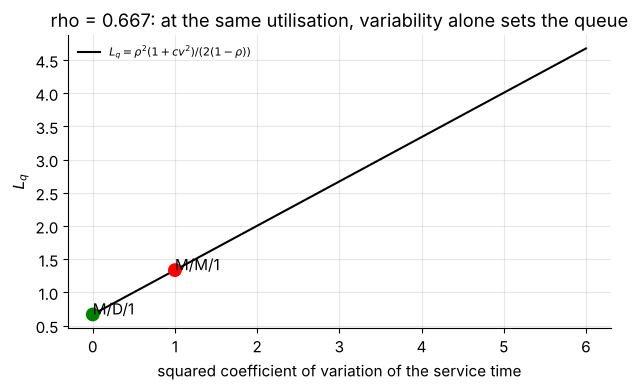

In [20]:
def pk_demo(rho=0.667):
    """Lq against the service-time cv^2 at fixed rho: a straight line (P-K), with M/D/1 and M/M/1 marked."""
    cv2 = np.linspace(0, 6, 100)
    Lq = rho**2 * (1 + cv2) / (2 * (1 - rho))
    plt.figure(figsize=(7, 3.8)); plt.plot(cv2, Lq, "k", label="$L_q=\\rho^2(1+cv^2)/(2(1-\\rho))$")
    plt.scatter([0, 1], [rho**2/(2*(1-rho)), rho**2/(1-rho)], c=["g", "r"], zorder=3, s=80)
    plt.annotate("M/D/1", (0, rho**2/(2*(1-rho)))); plt.annotate("M/M/1", (1, rho**2/(1-rho)))
    plt.xlabel("squared coefficient of variation of the service time"); plt.ylabel("$L_q$"); plt.legend(fontsize=8)
    plt.title(f"rho = {rho}: at the same utilisation, variability alone sets the queue"); plt.show()

show(pk_demo, rho=FloatSlider(min=0.1, max=0.95, step=0.05, value=0.667) if HAS_W else 0.667)

**Think about it** — (i) Rewrite P–K as $L_q=\frac{\rho^2}{1-\rho}\cdot\frac{1+cv^2}{2}$: what do the
two factors mean? (ii) The derivation on slide p. 35/66 used the mean residual service time
$E[S^2]/(2E[S])$ from Ch. 7 — which paradox is that, and why is it multiplied by $\rho$?
(iii) The heavy-tailed simulations converge slowly; why? (Think of the largest service
time in a sample.)

---
## Problem 6 — Bulk arrivals: airport security *(slides pp. 31–33/66; homework09 Q1 of 2025)*

> Customers arrive at a security checkpoint in batches of 1, 2, 3 or 4 with
> probabilities 0.4, 0.3, 0.2, 0.1; batches form $PP(\lambda)$ with $\lambda=2$ per minute.
> Customers are screened one by one, $\exp(\mu)$ with $\mu=5$ per minute. Compute $L$,
> $W$, $L_q$, $W_q$.

### Model
$M^{[X]}/M/1$: $\rho=\lambda E[X]/\mu$, $L=\frac{\rho+(\lambda/\mu)E[X^2]}{2(1-\rho)}$ (slide p. 31/66);
Little with the *customer* arrival rate $\lambda E[X]$; $L_q=L-\rho$ (slide p. 33/66).

In [21]:
lam, mu = 2.0, 5.0
q = np.array([0.4, 0.3, 0.2, 0.1]); sizes = np.arange(1, 5)
EX, EX2 = (sizes * q).sum(), (sizes**2 * q).sum()
rho = lam * EX / mu
L = (rho + lam / mu * EX2) / (2 * (1 - rho))
W = L / (lam * EX)
Lq = L - rho
Wq = Lq / (lam * EX)
print(f"E[X] = {EX}, E[X^2] = {EX2}, rho = {rho}   L = {L:.3f}   W = {W:.3f} min   Lq = {Lq:.3f}   Wq = {Wq:.3f} min")

E[X] = 2.0, E[X^2] = 5.0, rho = 0.8   L = 7.000   W = 1.750 min   Lq = 6.200   Wq = 1.550 min


In [22]:
check("E[X]",  EX,  2.0,  tol=1e-9)
check("E[X^2]", EX2, 5.0,  tol=1e-9)
check("rho = lam E[X]/mu", rho, 0.8, tol=1e-9)
check("L",      L,   7.0,  tol=1e-9)
check("W (min)", W,  1.75, tol=1e-9)
check("Lq",     Lq,  6.2,  tol=1e-9)
check("Wq (min)", Wq, 1.55, tol=1e-9)

[OK ] E[X]: got 2   (reference 2)
[OK ] E[X^2]: got 5   (reference 5)
[OK ] rho = lam E[X]/mu: got 0.8   (reference 0.8)
[OK ] L: got 7   (reference 7)
[OK ] W (min): got 1.75   (reference 1.75)
[OK ] Lq: got 6.2   (reference 6.2)
[OK ] Wq (min): got 1.55   (reference 1.55)


True

In [23]:
# --- Simulate the batches: an arrival sampler that returns the gaps between successive CUSTOMERS ----------------
def bulk_gaps(lam, q):
    """Inter-arrival sampler for M^[X]/M/1: a batch gap exp(lam) followed by (X-1) zero gaps."""
    sizes = np.arange(1, len(q) + 1)
    def sampler(r, n):
        out = []
        while len(out) < n:
            k = r.choice(sizes, p=q)
            out.extend([r.exponential(1 / lam)] + [0.0] * (k - 1))
        return np.array(out[:n])
    return sampler

ref = bulk_mm1(2.0, [0.4, 0.3, 0.2, 0.1], 5.0)                             # independent of your TODO
res = simulate_queue(bulk_gaps(2.0, [0.4, 0.3, 0.2, 0.1]), 5.0, T=40_000, rng=rng, warmup=500)
single = simulate_queue(4.0, 5.0, T=40_000, rng=rng, warmup=500)         # single arrivals at the same customer rate
print(f"bulk arrivals:   L sim {res['L']:.3f} (theory {ref['L']:.3f})   W sim {res['W']:.3f} (theory {ref['W']:.3f})   Lq sim {res['Lq']:.3f} ({ref['Lq']:.3f})")
print(f"single arrivals, same customer rate 4/min and rho = 0.8:  L sim {single['L']:.3f} (theory 4)  W sim {single['W']:.3f} (theory 1)")

bulk arrivals:   L sim 6.872 (theory 7.000)   W sim 1.714 (theory 1.750)   Lq sim 6.072 (6.200)
single arrivals, same customer rate 4/min and rho = 0.8:  L sim 3.909 (theory 4)  W sim 0.978 (theory 1)


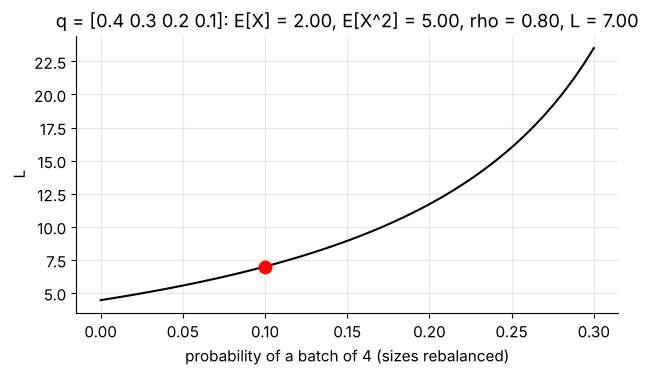

In [24]:
def bulk_demo(p4=0.1):
    """Keep E[X] = 2 but move mass to the extremes: L grows with E[X^2] at the same rho."""
    # batch sizes 1..4 with mean 2: q = (0.5 - p4 + ..) -- use the family q1 = 0.4 + p4', ... simplest: mixture of (1,3) and (2) and (1,4)
    q = np.array([0.4 + 0.5*(p4 - 0.1), 0.3 - 1.5*(p4 - 0.1), 0.2, p4]); q = np.clip(q, 0, 1); q = q / q.sum()
    r = bulk_mm1(2.0, q, 5.0)
    xx = np.linspace(0, 0.3, 50); LL = [bulk_mm1(2.0, np.clip(np.array([0.4 + 0.5*(x - 0.1), 0.3 - 1.5*(x - 0.1), 0.2, x]), 0, 1) / np.clip(np.array([0.4 + 0.5*(x - 0.1), 0.3 - 1.5*(x - 0.1), 0.2, x]), 0, 1).sum(), 5.0)["L"] for x in xx]
    plt.figure(figsize=(7, 3.6)); plt.plot(xx, LL, "k"); plt.scatter([p4], [r["L"]], c="r", s=80, zorder=3)
    plt.xlabel("probability of a batch of 4 (sizes rebalanced)"); plt.ylabel("L"); plt.title(f"q = {q.round(3)}: E[X] = {r['EX']:.2f}, E[X^2] = {r['EX2']:.2f}, rho = {r['rho']:.2f}, L = {r['L']:.2f}"); plt.show()

show(bulk_demo, p4=FloatSlider(min=0.0, max=0.3, step=0.02, value=0.1) if HAS_W else 0.1)

**Think about it** — (i) With $X\equiv1$ the formula returns $\rho/(1-\rho)$; check it. (ii) Why
does $E[X^2]$ (not only $E[X]$) appear — what does a large batch do to the people at its
end? (iii) Which arrival rate goes into Little's law here, and what would go wrong with the
batch rate $\lambda$?

---
## Problem 7 — Final-style: reneging and balking *(2025 final Q2; homework08 Q3)*

> Potential customers arrive at a single-server queue according to $PP(\lambda)$. A
> customer who finds $i$ customers in the system balks (leaves at once) with probability
> $i/(i+1)$. Every customer who joins has an $\exp(\theta)$ patience time: if service has
> not started by then, he or she leaves without service (reneging). Service times are
> $\exp(\mu)$. Model the number in the system as a CTMC and find its stationary distribution
> and the fractions of customers lost to balking and to reneging.

### Model
A birth–death chain: births $\lambda_i=\lambda\cdot\frac1{i+1}$ (the joining probability),
deaths $\mu_i=\mu+(i-1)\theta$ for $i\ge1$ (one in service, $i-1$ impatient waiters).
There is no closed form, but `birth_death_stationary` on a long truncated chain is exact
to machine precision. Numbers: $\lambda=2$, $\mu=1$, $\theta=0.5$.

In [25]:
lam, mu, theta = 2.0, 1.0, 0.5
K = 80                                                        # truncation level for the numerics (p_80 ~ 0)
births = np.array([lam / (i + 1) for i in range(K)])          # rate i -> i+1
deaths = np.array([mu + i * theta for i in range(K)])         # rate i+1 -> i : service + i waiting customers
p = birth_death_stationary(births, deaths)
n = np.arange(K + 1)
L = (n * p).sum()
frac_balk = (p * n / (n + 1)).sum()                          # PASTA: an arrival sees state n and balks w.p. n/(n+1)
frac_renege = (p[1:] * (n[1:] - 1) * theta).sum() / lam      # reneging rate / arrival rate
print(f"p_0..p_5 = {p[:6].round(4)}   L = {L:.4f}   balk {frac_balk:.4f}   renege {frac_renege:.4f}   served {1 - frac_balk - frac_renege:.4f}")

p_0..p_5 = [0.2049 0.4099 0.2732 0.0911 0.0182 0.0024]   L = 1.3161   balk 0.4722   renege 0.1303   served 0.3975


In [26]:
b_ref, d_ref = reneging_balking_rates(2.0, 1.0, 0.5, 80)
p_ref = birth_death_stationary(b_ref, d_ref); n_ref = np.arange(81)
check("birth rates (max abs error)", None if births is Ellipsis else float(np.abs(np.asarray(births) - b_ref).max()), 0.0, tol=1e-9)
check("death rates (max abs error)", None if deaths is Ellipsis else float(np.abs(np.asarray(deaths) - d_ref).max()), 0.0, tol=1e-9)
check("L",            L,           (n_ref * p_ref).sum(), tol=1e-6)
check("balking fraction", frac_balk,   (p_ref * n_ref / (n_ref + 1)).sum(), tol=1e-6)
check("reneging fraction", frac_renege, (p_ref[1:] * (n_ref[1:] - 1) * 0.5).sum() / 2.0, tol=1e-6)

[OK ] birth rates (max abs error): got 0   (reference 0)
[OK ] death rates (max abs error): got 0   (reference 0)
[OK ] L: got 1.31609   (reference 1.31609)
[OK ] balking fraction: got 0.472209   (reference 0.472209)
[OK ] reneging fraction: got 0.130256   (reference 0.130256)


np.True_

simulation: L 1.3174   balked 0.4768   reneged 0.1310   served 0.3971
theory:     L 1.3161   balked 0.4722   reneged 0.1303


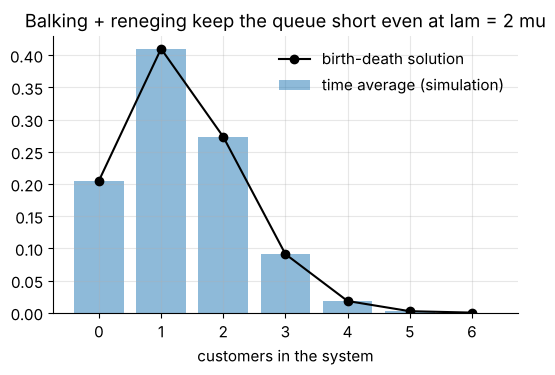

In [27]:
# --- Simulate with balking and patience (the simulator counts both kinds of loss) --------------------------------
res = simulate_queue(2.0, 1.0, T=40_000, rng=rng, balk=lambda n: n / (n + 1), patience=0.5, warmup=300)
b_ref, d_ref = reneging_balking_rates(2.0, 1.0, 0.5, 80); p_ref = birth_death_stationary(b_ref, d_ref); n_ref = np.arange(81)
print(f"simulation: L {res['L']:.4f}   balked {res['lost_balk']/res['arrivals']:.4f}   reneged {res['lost_renege']/res['arrivals']:.4f}   served {res['served']/res['arrivals']:.4f}")
print(f"theory:     L {(n_ref*p_ref).sum():.4f}   balked {(p_ref*n_ref/(n_ref+1)).sum():.4f}   reneged {(p_ref[1:]*(n_ref[1:]-1)*0.5).sum()/2:.4f}")
plt.figure(figsize=(6, 3.6)); plt.bar(np.arange(7), res["p_time"][:7], alpha=.5, label="time average (simulation)"); plt.plot(np.arange(7), p_ref[:7], "ko-", label="birth-death solution")
plt.xlabel("customers in the system"); plt.legend(); plt.title("Balking + reneging keep the queue short even at lam = 2 mu"); plt.show()

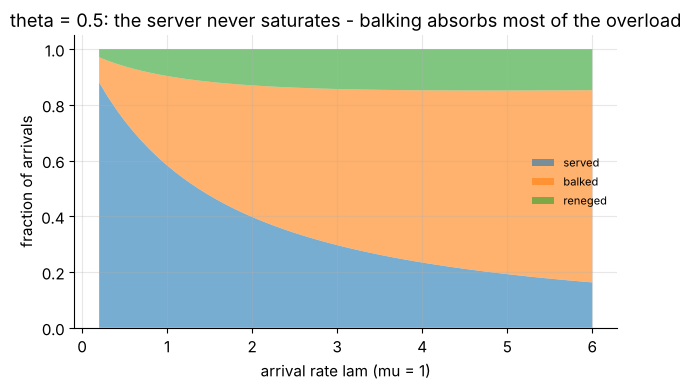

In [28]:
def reneging_demo(theta=0.5):
    """Fractions served / balked / reneged as functions of the arrival rate, for a chosen impatience theta (mu = 1)."""
    ll = np.linspace(0.2, 6, 60); out = []
    for l in ll:
        b, d = reneging_balking_rates(l, 1.0, theta, 120); p = birth_death_stationary(b, d); n = np.arange(121)
        balk = (p * n / (n + 1)).sum(); ren = (p[1:] * (n[1:] - 1) * theta).sum() / l
        out.append((1 - balk - ren, balk, ren))
    out = np.array(out)
    plt.figure(figsize=(7, 3.8)); plt.stackplot(ll, out.T, labels=["served", "balked", "reneged"], alpha=.6)
    plt.xlabel("arrival rate lam (mu = 1)"); plt.ylabel("fraction of arrivals"); plt.legend(loc="center right", fontsize=8)
    plt.title(f"theta = {theta}: the server never saturates - balking absorbs most of the overload"); plt.show()

show(reneging_demo, theta=FloatSlider(min=0.0, max=3, step=0.1, value=0.5) if HAS_W else 0.5)

**Think about it** — (i) Why is this chain stable for *every* $\lambda$, even with $\theta=0$?
(ii) The reneging fraction is "reneging rate / arrival rate"; write the reneging rate as a
sum over states and explain the factor $(i-1)$. (iii) On the exam only the CTMC (rate
diagram and balance equations) was asked — write the balance equation of state $i$.

---
## Section 8 — $G/G/1$ and $G/G/m$: approximations only *(slide p. 37/66; Companion Appendix A; homework09 Q4 of 2025)*

> There are 4 identical machines in a shop. Jobs arrive for processing at one of the
> machines; the inter-arrival times follow a Gamma distribution with mean 20 min and
> standard deviation 5 min. The processing time at each machine is a constant 1 hour.
> A job that finds all machines busy waits (infinite queue). Compute an approximate
> average number of jobs in the system, $L$.

Without Poisson arrivals and exponential service there is no exact formula; the PLMS
handout gives approximations in terms of the squared coefficients of variation
$C_a^2=\mathrm{Var}(T)/E[T]^2$, $C_s^2=\mathrm{Var}(S)/E[S]^2$. For $G/G/m$:
$\rho=\lambda/(m\mu)$, $\alpha_m=(\rho^m+\rho)/2$ if $\rho>0.7$ else $\rho^{(m+1)/2}$,
$W_q\approx\frac{\alpha_m}{\mu}\frac1{1-\rho}\frac{C_a^2+C_s^2}{2m}$, then $L_q=\lambda W_q$,
$L=L_q+\lambda/\mu$ (Little on the machines: the in-service part is exact).

In [29]:
lam, mu, m = 1/20, 1/60, 4                                    # per minute
ca2, cs2 = (5/20)**2, 0.0                                       # Gamma arrivals, cv 0.25; constant service
approx = ggm_approx(lam, mu, m, ca2, cs2)
print(f"rho = {approx['rho']:.3f}  alpha_m = {approx['alpha_m']:.4f}  Wq ~ {approx['Wq']:.3f} min  Lq ~ {approx['Lq']:.4f}  L ~ {approx['L']:.3f} jobs")
# simulate the G/D/4 shop: Gamma(shape 16, scale 1.25) inter-arrivals have mean 20 and sd 5; 60-min constant jobs
gamma_arr = lambda r, n: r.gamma(16, 1.25, n)
sim = simulate_queue(gamma_arr, lambda r, n: np.full(n, 60.0), T=2_000_000, rng=rng, s=4, warmup=5_000)   # 100,000 jobs
print(f"simulation: L = {sim['L']:.3f}   Lq = {sim['Lq']:.4f}   Wq = {sim['Wq']:.3f} min")
print("L agrees (3.05 vs 3.00) because L is dominated by the jobs IN SERVICE, lam/mu = 3, which Little's law gives exactly.")
print("The queue itself is about 20x smaller than the formula says: nearly regular arrivals and constant jobs hardly ever")
print("collide. For the homework question (L) the approximation is fine; for Wq it is not. The next cell maps out when it is.")

rho = 0.750  alpha_m = 0.5332  Wq ~ 1.000 min  Lq ~ 0.0500  L ~ 3.050 jobs


simulation: L = 3.005   Lq = 0.0022   Wq = 0.045 min
L agrees (3.05 vs 3.00) because L is dominated by the jobs IN SERVICE, lam/mu = 3, which Little's law gives exactly.
The queue itself is about 20x smaller than the formula says: nearly regular arrivals and constant jobs hardly ever
collide. For the homework question (L) the approximation is fine; for Wq it is not. The next cell maps out when it is.


In [30]:
# --- Where the G/G/m formula is good and where it is not: scan the variability at rho = 0.75, m = 4 -------------------
def gamma_law(mean, scv):                                                       # Gamma sampler with given mean and cv^2
    return (lambda r, n: np.full(n, mean)) if scv == 0 else (lambda r, n, k=1/scv: r.gamma(k, mean / k, n))
print(f"{'C_a^2':>6} {'C_s^2':>6} {'Wq approx':>10} {'Wq sim':>8}   (M/M/4 exact: {mms(lam, mu, 4)['Wq']:.2f})")
for ca2_, cs2_ in [(1.0, 1.0), (1.0, 0.25), (0.5, 0.5), (1.0, 0.0), (0.25, 0.0), (1/16, 0.0)]:
    ap = ggm_approx(lam, mu, m, ca2_, cs2_)
    sm = simulate_queue(gamma_law(20.0, ca2_), gamma_law(60.0, cs2_), T=2_000_000, rng=rng, s=4, warmup=5_000)
    print(f"{ca2_:>6.3f} {cs2_:>6.2f} {ap['Wq']:>10.2f} {sm['Wq']:>8.2f}")
print("Moderate variability (Poisson or Erlang-2 arrivals, cv >= 0.5 service): within 10-20 %.  Nearly deterministic arrivals")
print("AND service: the real queue is almost empty, but the formula still scales with (C_a^2 + C_s^2) and overestimates badly.")
print("It is an estimate, not a theorem.")

 C_a^2  C_s^2  Wq approx   Wq sim   (M/M/4 exact: 30.57)


 1.000   1.00      31.99    30.43


 1.000   0.25      20.00    19.03


 0.500   0.50      16.00    13.46


 1.000   0.00      16.00    16.54


 0.250   0.00       4.00     1.72


 0.062   0.00       1.00     0.05
Moderate variability (Poisson or Erlang-2 arrivals, cv >= 0.5 service): within 10-20 %.  Nearly deterministic arrivals
AND service: the real queue is almost empty, but the formula still scales with (C_a^2 + C_s^2) and overestimates badly.
It is an estimate, not a theorem.


In [31]:
# --- G/G/1: the four approximations against simulation for Erlang(4) arrivals and lognormal service (cv 1.5) ---------
rho_grid = [0.5, 0.7, 0.9]; ca2, cs2 = 0.25, 2.25
print(f"{'rho':>4} {'kingman':>8} {'h1':>7} {'h2':>7} {'h3':>7} {'simulation':>11}")
for rho_ in rho_grid:
    lam_ = rho_                                                      # mu = 1
    arr = lambda r, n, l=lam_: r.gamma(4, 1 / (4 * l), n)
    svc = lambda r, n: r.lognormal(-0.5*math.log(1 + cs2), math.sqrt(math.log(1 + cs2)), n)
    sim = simulate_queue(arr, svc, T=150_000, rng=rng, warmup=2_000)
    row = [gg1_approx(lam_, 1.0, ca2, cs2, meth)["L"] for meth in ("kingman", "h1", "h2", "h3")]
    print(f"{rho_:>4} {row[0]:>8.3f} {row[1]:>7.3f} {row[2]:>7.3f} {row[3]:>7.3f} {sim['L']:>11.3f}")
print("All four are exact for M/M/1 (ca2 = cs2 = 1) and get better as rho -> 1 (heavy traffic); use them as estimates, not as truth.")

 rho  kingman      h1      h2      h3  simulation


 0.5    1.125   0.922   0.964   1.172       1.082


 0.7    2.742   2.407   2.454   2.807       2.487


 0.9   11.025  10.565  10.588  11.109      10.147
All four are exact for M/M/1 (ca2 = cs2 = 1) and get better as rho -> 1 (heavy traffic); use them as estimates, not as truth.


**Think about it** — (i) Whatever the variability, $L$ of the shop stays close to
$\lambda/\mu=3$ — which law guarantees that the *in-service* part of $L$ is exactly $\lambda/\mu$,
for any arrival and service distributions?
(ii) Kingman's formula is
$W_q\approx\frac{\rho}{1-\rho}\cdot\frac{C_a^2+C_s^2}{2}\cdot\frac1\mu$: three factors — utilisation,
variability, service time. Which factor does a manager control most cheaply?
(iii) Why would you *not* use these formulas to decide between 4 slow machines and
2 fast ones when $C_a^2=C_s^2=0$? (Look at the last rows of the scan.)

---
## Wrap-up

| question | tool | answer |
|---|---|---|
| car wash (#1) | $M/M/1/K$, $\lambda(1-p_K)$ | $p_K=0.2$, $L=2$, $W=25$ min (not $20$) |
| $M/M/5/5$, fast food (#2) | $M/M/s/K$ | $p_5=1/326$, $L=0.997$, $W=12$ min; $M/M/2/4$: loss 12.4 %, $L=1.73$, $W=0.66$ min |
| telephone lines (#3) | Erlang B, revenue $ca(1-B)-dK$ | $K^*=6$ for $a=6$, $d=0.5$; loss law insensitive to the call length |
| $M/M/2/K$ (#4, final-style) | truncation | renormalise the $M/M/2$ weights: $p^{(4)}=(0.348,0.348,0.174,0.087,0.043)$ |
| web server (#5) | Pollaczek–Khinchine | $\rho=2/3$, $L_q=4.83$, $W=16.5$ s ($4$ s $+2$ s if exponential) |
| airport (#6) | $M^{[X]}/M/1$ | $L=7$, $W=1.75$ min, $L_q=6.2$, $W_q=1.55$ min |
| reneging + balking (#7, final-style) | birth–death with $\lambda/(i+1)$, $\mu+(i-1)\theta$ | $L=1.32$; 47 % balk, 13 % renege, 40 % served |
| machine shop (#8) | $G/G/m$ approximation | $L\approx3.05$ (simulation $3.00$): almost queue-free; the formula's $W_q$ is $20\times$ too big here — trust it for moderate variability only |

**Next:** CP13 — networks of queues: traffic equations, the product form, the Bagels
store, tandem and feedback queues, routing and Braess' paradox.